#                    Multivariate Analysis Lab

#problem-2 :
for Iris datasets show first five row .then perform


1.   PCA
2.   FA

3.   LDA
4.   CCA

5.   K means clustering









solution:
#1. Perform PCA

In [3]:
#............................................................
#a)PCA and optimal components
#............................................................
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


Load iris dataset unscaled ,show frist five row


In [4]:
iris=load_iris()
X=pd.DataFrame(iris.data,columns=iris.feature_names)
y=["Species"]
#for showing last five row
X_5=X.tail(5)
print(X_5)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8


Standardize the data and perfom pca

In [5]:
#scaled data
X_scaled=StandardScaler().fit_transform(X)
print("Scaled datasets:",X_scaled)
#PCA
pca=PCA()
X_pca=pca.fit_transform(X_scaled)

#PCA all components ,variance expained and cumulative variance
variance_ratio=pca.explained_variance_ratio_
cumulative_variance=variance_ratio.cumsum()

#table
pca_df=pd.DataFrame({
"PC":range(1,len(variance_ratio)+1),
"variance":variance_ratio,
"Cumulative":cumulative_variance
})

print(pca_df)

Scaled datasets: [[-9.00681170e-01  1.01900435e+00 -1.34022653e+00 -1.31544430e+00]
 [-1.14301691e+00 -1.31979479e-01 -1.34022653e+00 -1.31544430e+00]
 [-1.38535265e+00  3.28414053e-01 -1.39706395e+00 -1.31544430e+00]
 [-1.50652052e+00  9.82172869e-02 -1.28338910e+00 -1.31544430e+00]
 [-1.02184904e+00  1.24920112e+00 -1.34022653e+00 -1.31544430e+00]
 [-5.37177559e-01  1.93979142e+00 -1.16971425e+00 -1.05217993e+00]
 [-1.50652052e+00  7.88807586e-01 -1.34022653e+00 -1.18381211e+00]
 [-1.02184904e+00  7.88807586e-01 -1.28338910e+00 -1.31544430e+00]
 [-1.74885626e+00 -3.62176246e-01 -1.34022653e+00 -1.31544430e+00]
 [-1.14301691e+00  9.82172869e-02 -1.28338910e+00 -1.44707648e+00]
 [-5.37177559e-01  1.47939788e+00 -1.28338910e+00 -1.31544430e+00]
 [-1.26418478e+00  7.88807586e-01 -1.22655167e+00 -1.31544430e+00]
 [-1.26418478e+00 -1.31979479e-01 -1.34022653e+00 -1.44707648e+00]
 [-1.87002413e+00 -1.31979479e-01 -1.51073881e+00 -1.44707648e+00]
 [-5.25060772e-02  2.16998818e+00 -1.45390138

PCs for 95% variance expalanation,screeplot

Optimal Components: 2


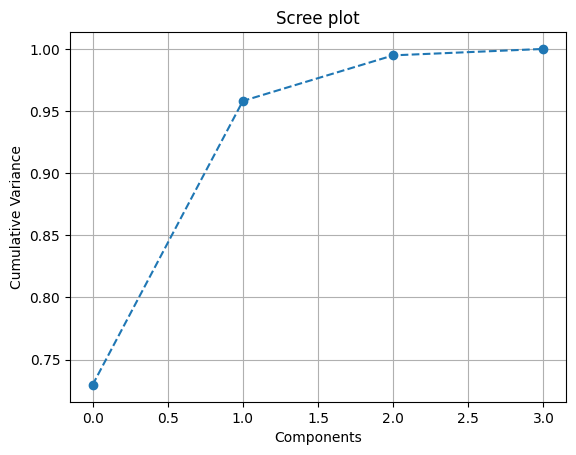

Components needed for 95% variance: 2


In [6]:
#Optimal Components for 95% expalantion
k=(cumulative_variance>=0.95).argmax()+1
print("Optimal Components:",k)



#.......................................................................................
 #screeplot
#.......................................................................................

plt.plot(cumulative_variance,marker='o',linestyle='--')
plt.xlabel("Components")
plt.ylabel("Cumulative Variance")
plt.title("Scree plot")
plt.grid()
plt.show()
print("Components needed for 95% variance:",k)

plotting pc's vs cumulative explained variance

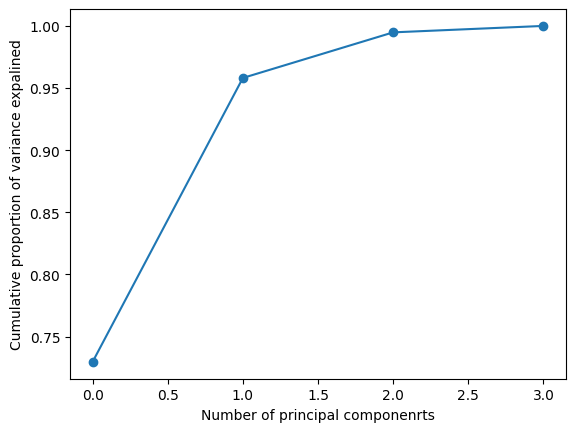

In [7]:
plt.plot(cumulative_variance,"-o")
plt.xlabel("Number of principal componenrts")
plt.ylabel("Cumulative proportion of variance expalined")
plt.show()

Dimensionality reduction and pca plot for 2 components

          PC1       PC2
0   -2.264703  0.480027
1   -2.080961 -0.674134
2   -2.364229 -0.341908
3   -2.299384 -0.597395
4   -2.389842  0.646835
..        ...       ...
145  1.870503  0.386966
146  1.564580 -0.896687
147  1.521170  0.269069
148  1.372788  1.011254
149  0.960656 -0.024332

[150 rows x 2 columns]


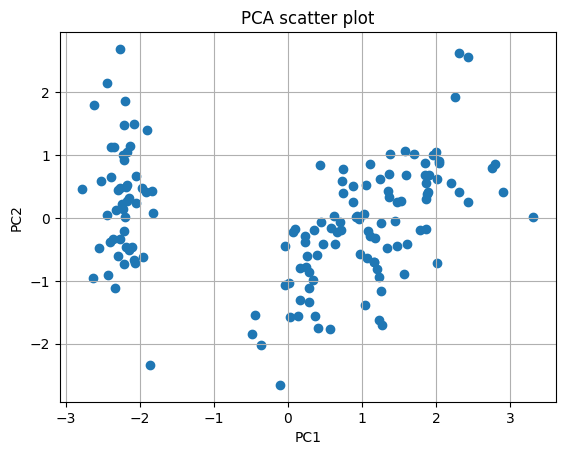

In [8]:
pca_2d=PCA(n_components=2)
X_pca_2d=pca_2d.fit_transform(X_scaled)
pca_df=pd.DataFrame(X_pca_2d,columns=["PC1","PC2"])
print(pca_df)
plt.scatter(X_pca_2d[:,0],X_pca_2d[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA scatter plot")
plt.grid()
plt.show()

#2.  Factor analysis

Bartlett and KMO test

In [9]:
!pip install factor_analyzer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=f64df646f7aadc60bc661d10e1b6013afe5fbaf893a5b80067f44089d684d377
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer


In [10]:
from sklearn.decomposition import FactorAnalysis
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity,calculate_kmo
from factor_analyzer.factor_analyzer import calculate_kmo

chi_square_value,p_value=calculate_bartlett_sphericity(X)
print("Bartlett Test:",chi_square_value,p_value)

kmo_all,kmo_model=calculate_kmo(X)
print("Bartlet Test:",kmo_all,kmo_model)



Bartlett Test: 706.9592430234751 1.9226796044147852e-149
Bartlet Test: [0.58406029 0.26957462 0.53074842 0.63420655] 0.5400766750097237


Perform factor analysis

In [38]:
fa=FactorAnalysis(n_components=2)
X_fa=fa.fit_transform(X_scaled)
fa_loading=fa.components_
print("Factor Analysis Loading:",fa_loading)

Factor Analysis Loading: [[ 0.88096009 -0.41691605  0.99918858  0.96228895]
 [-0.4472869  -0.55390036  0.01915283  0.05840206]]


Factor plot and compare with PC's plot


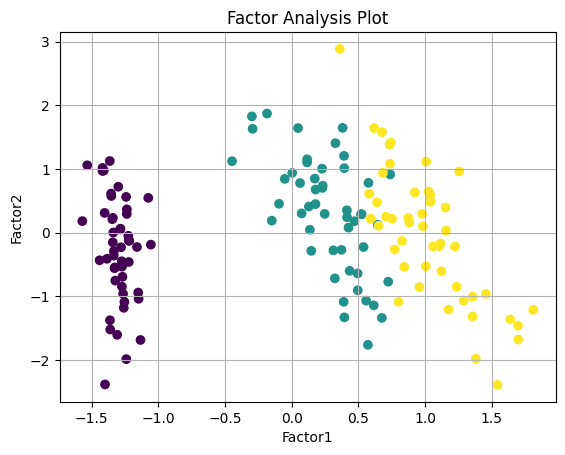

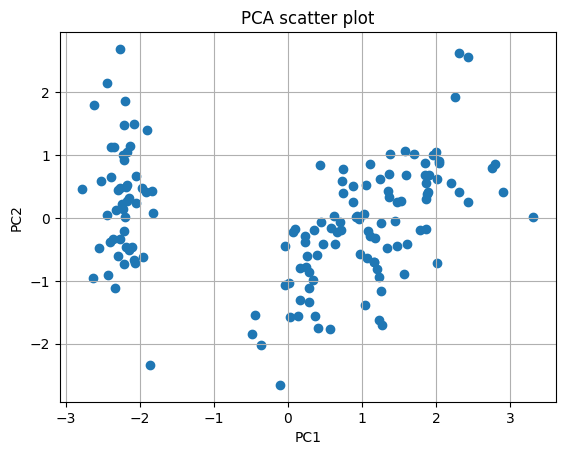

Comparison between PCA and FA
PCA finds maximum variance directions.
FA finds hidden latent factors.
PCA preserves total variance.
FA explains correlations among variables.
PCA gives principal components.
FA gives factor loadings.


In [12]:
#factor plot
plt.scatter(X_fa[:,0],X_fa[:,1],c=iris.target)
plt.xlabel("Factor1")
plt.ylabel("Factor2")
plt.title("Factor Analysis Plot")
plt.grid()
plt.show()

#PCA plot

plt.scatter(X_pca_2d[:,0],X_pca_2d[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA scatter plot")
plt.grid()
plt.show()
# Comparison
print("Comparison between PCA and FA")
print("PCA finds maximum variance directions.")
print("FA finds hidden latent factors.")
print("PCA preserves total variance.")
print("FA explains correlations among variables.")
print("PCA gives principal components.")
print("FA gives factor loadings.")



Perform LDA


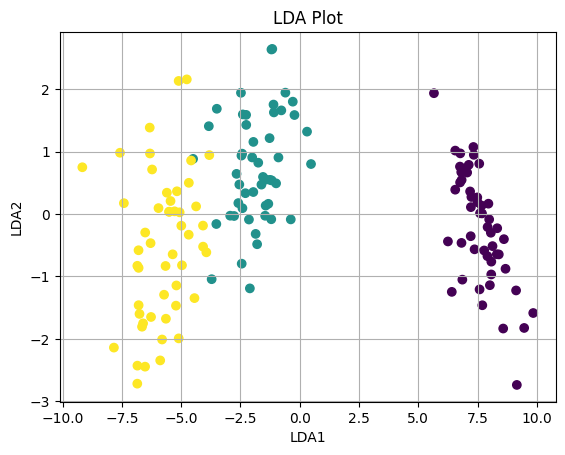

In [39]:
#f)Perform LDA and LDA plot (number of class=3(sestosa,versicolor,virginica))
#class-1=2

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


lda=LinearDiscriminantAnalysis(n_components=2)
X_lda=lda.fit_transform(X_scaled,iris.target)

#LDA plot
plt.scatter(X_lda[:,0],X_lda[:,1],c=iris.target)
plt.xlabel("LDA1")
plt.ylabel("LDA2")
plt.title("LDA Plot")
plt.grid()
plt.show()


### 4.Canonical Correlation Analysis

In [14]:
#g)Canonical Correlation Analysis (CCA)


from sklearn.cross_decomposition import CCA
#sepal variable
X1=X.iloc[:,0:2]

#petal variable
X2=X.iloc[:,2:4]

cca=CCA(n_components=1)
X_cca,Y_cca=cca.fit_transform(X1,X2)
print(pd.DataFrame(X_cca).corrwith(pd.DataFrame(Y_cca)))

0    0.940969
dtype: float64


CCA plot

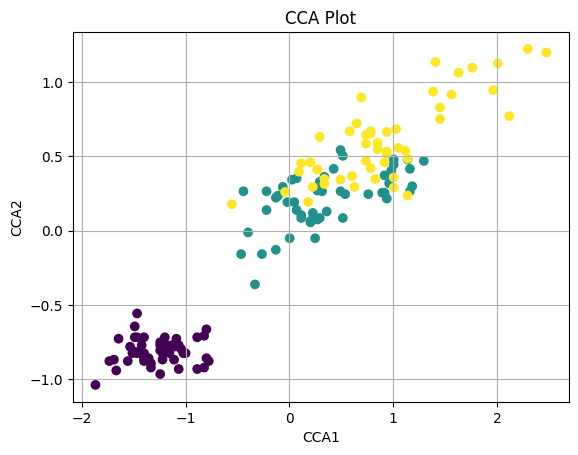

In [15]:
#cca plot
plt.scatter(X_cca[:,0],Y_cca[:,0],c=iris.target)
plt.xlabel("CCA1")
plt.ylabel("CCA2")
plt.title("CCA Plot")
plt.grid()
plt.show()

#Problem 3:
K Means Clustering for iris datasets

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


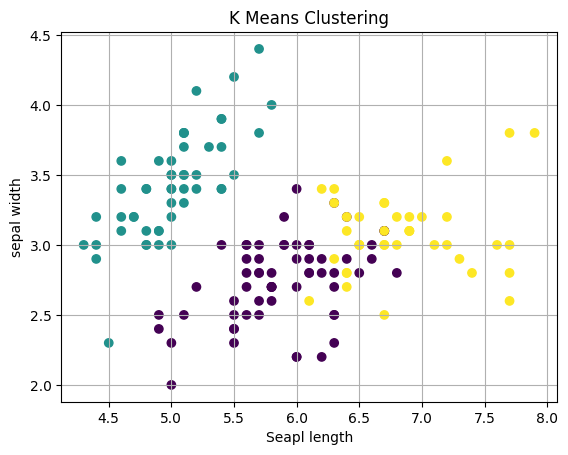

In [16]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=3, random_state=42)
clusters=kmeans.fit_predict(X)
print(clusters)

#plot k means
plt.scatter(X.iloc[:,0],X.iloc[:,1],c=clusters)
plt.xlabel("Seapl length")
plt.ylabel("sepal width")
plt.title("K Means Clustering")
plt.grid()
plt.show()

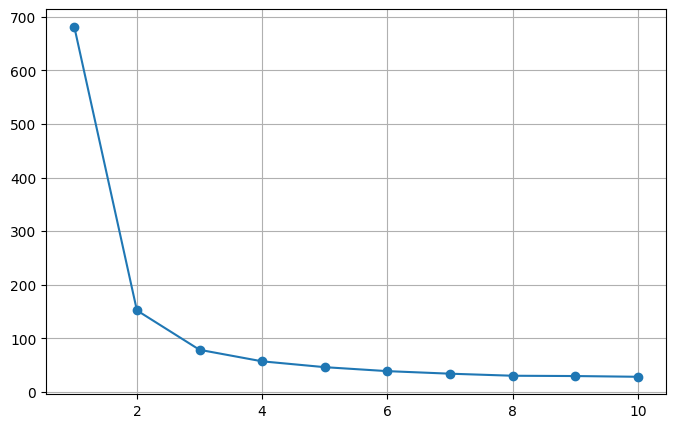

In [25]:
#from sklearn.cluster import make_blobs
#x,Y=make_blobs(n_samples=500,center=3,random_state=42)  #for 500 synthetic data.all same
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
inertia=[]
for k in range (1,11):
    kmean=KMeans(n_clusters=k,random_state=42)
    X_kmean=kmean.fit_predict(X)
    inertia.append(kmean.inertia_)
plt.figure(figsize=(8,5))
plt.plot(range(1,11),inertia,marker="o")
plt.grid()
plt.show()


In [33]:
hierarchy = AgglomerativeClustering(linkage='ward')
yhict=hierarchy.fit_predict(X)



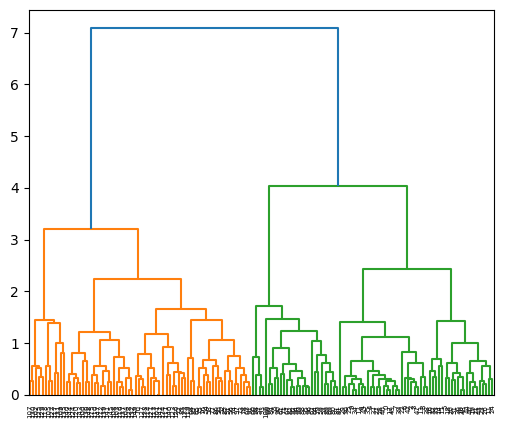

In [37]:
from scipy.cluster.hierarchy import linkage,dendrogram
z=linkage(X,"complete")
plt.figure(figsize=(6,5))
dendrogram(z)
plt.show()
